In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import anndata as ad
import scanpy as sc
import scipy.sparse as sp

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
mpl.rcParams["figure.figsize"] = (6, 5)

print(f"scanpy  {sc.__version__}")
print(f"anndata {ad.__version__}")

scanpy  1.10.3
anndata 0.10.9


In [2]:
RNA_PATH = "../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad"
PPS_META = "../data/metadata/metadata_RNA_PPS.csv"

CELL_TYPES = {
    "Glu": {
        "class_name": "Neuronal: Glutamatergic",
        "atac_path":  "../data/processed/count_matrix_glu.txt",
        "pb_path":    "../data/processed/pseudobulk_RNA_Glu.csv",
    },
    "Gaba": {
        "class_name": "Neuronal: GABAergic",
        "atac_path":  "../data/processed/count_matrix_gaba.txt",
        "pb_path":    "../data/processed/pseudobulk_RNA_Gaba.csv",
    },
}

print("Fichiers d'entrée :")
print(f"  RNA h5ad : {RNA_PATH}  → existe: {os.path.exists(RNA_PATH)}")
for ct, cfg in CELL_TYPES.items():
    print(f"  ATAC {ct}  : {cfg['atac_path']}  → existe: {os.path.exists(cfg['atac_path'])}")


Fichiers d'entrée :
  RNA h5ad : ../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad  → existe: True
  ATAC Glu  : ../data/processed/count_matrix_glu.txt  → existe: True
  ATAC Gaba  : ../data/processed/count_matrix_gaba.txt  → existe: True


In [3]:
adata_rna = sc.read_h5ad(RNA_PATH)
print(adata_rna)
print(f"\nDonors total       : {adata_rna.obs['Donor ID'].nunique()}")
print(f"Cellules total     : {adata_rna.n_obs:,}")
print(f"\nClasses disponibles:")
print(adata_rna.obs["Class"].value_counts().to_string())

AnnData object with n_obs × n_vars = 1957283 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in mo

In [4]:
adata_rna.var["mt"] = adata_rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_rna, qc_vars=["mt"], percent_top=None, log1p=True, inplace=True
)

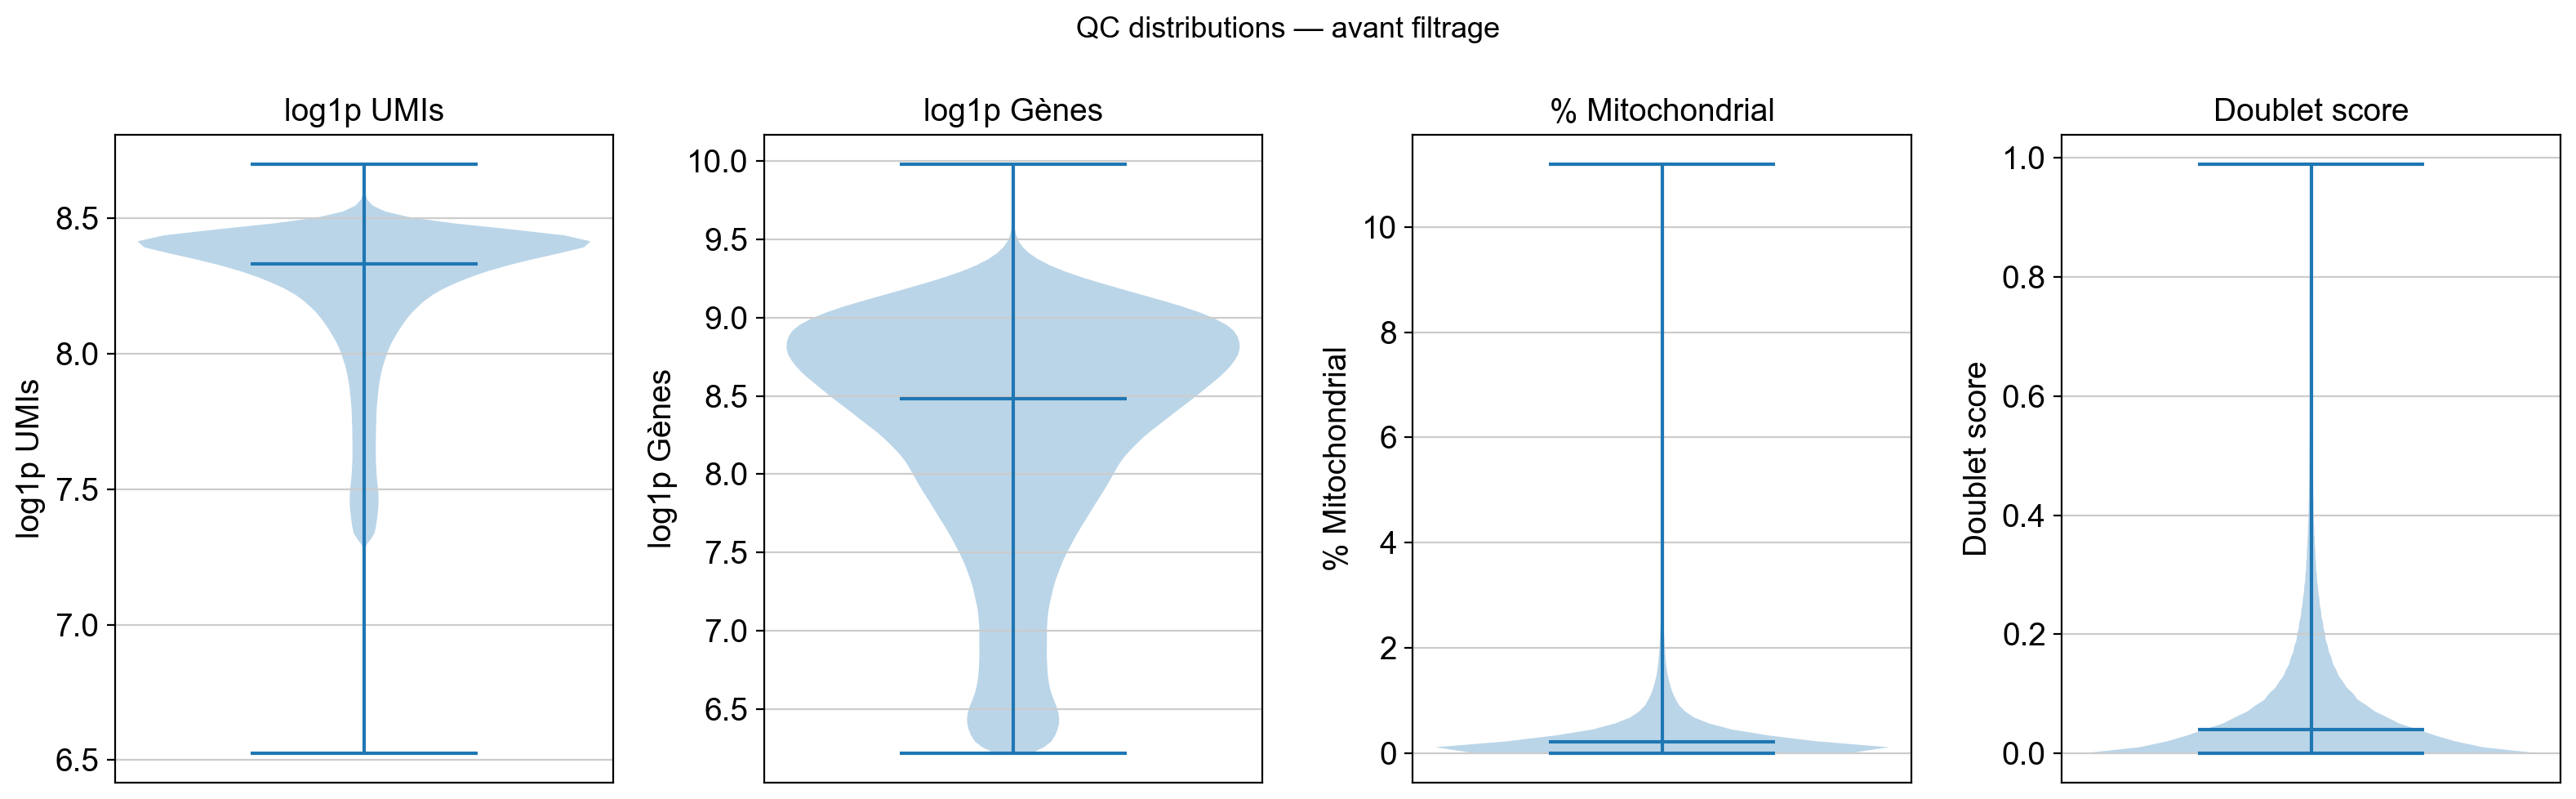

       log1p_total_counts  log1p_n_genes_by_counts  pct_counts_mt  \
count         1957283.000              1957283.000    1957283.000   
mean                8.228                    8.269          0.374   
std                 0.276                    0.764          0.506   
min                 6.526                    6.217          0.000   
25%                 8.162                    7.871          0.085   
50%                 8.332                    8.480          0.214   
75%                 8.409                    8.843          0.452   
max                 8.699                    9.982         11.195   

       Doublet score  
count    1957283.000  
mean           0.090  
std            0.140  
min            0.000  
25%            0.010  
50%            0.040  
75%            0.106  
max            0.990  


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics = [
    ("log1p_total_counts",      "log1p UMIs",          "steelblue"),
    ("log1p_n_genes_by_counts", "log1p Gènes",         "steelblue"),
    ("pct_counts_mt",           "% Mitochondrial",     "tomato"),
    ("Doublet score",           "Doublet score",        "orange"),
]

for ax, (col, label, color) in zip(axes, metrics):
    ax.violinplot(adata_rna.obs[col].dropna(), showmedians=True)
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_ylabel(label)

plt.suptitle("QC distributions — avant filtrage", fontsize=13)
plt.tight_layout()
plt.show()

print(adata_rna.obs[
    ["log1p_total_counts", "log1p_n_genes_by_counts", "pct_counts_mt", "Doublet score"]
].describe().round(3))

In [6]:
qc_thresholds = {
    "log1p_total_counts"      : ("min", 7.0),
    "log1p_n_genes_by_counts" : ("min", 7.5),
    "pct_counts_mt"           : ("max", 5.0),
    "Doublet score"           : ("max", 0.3),
}

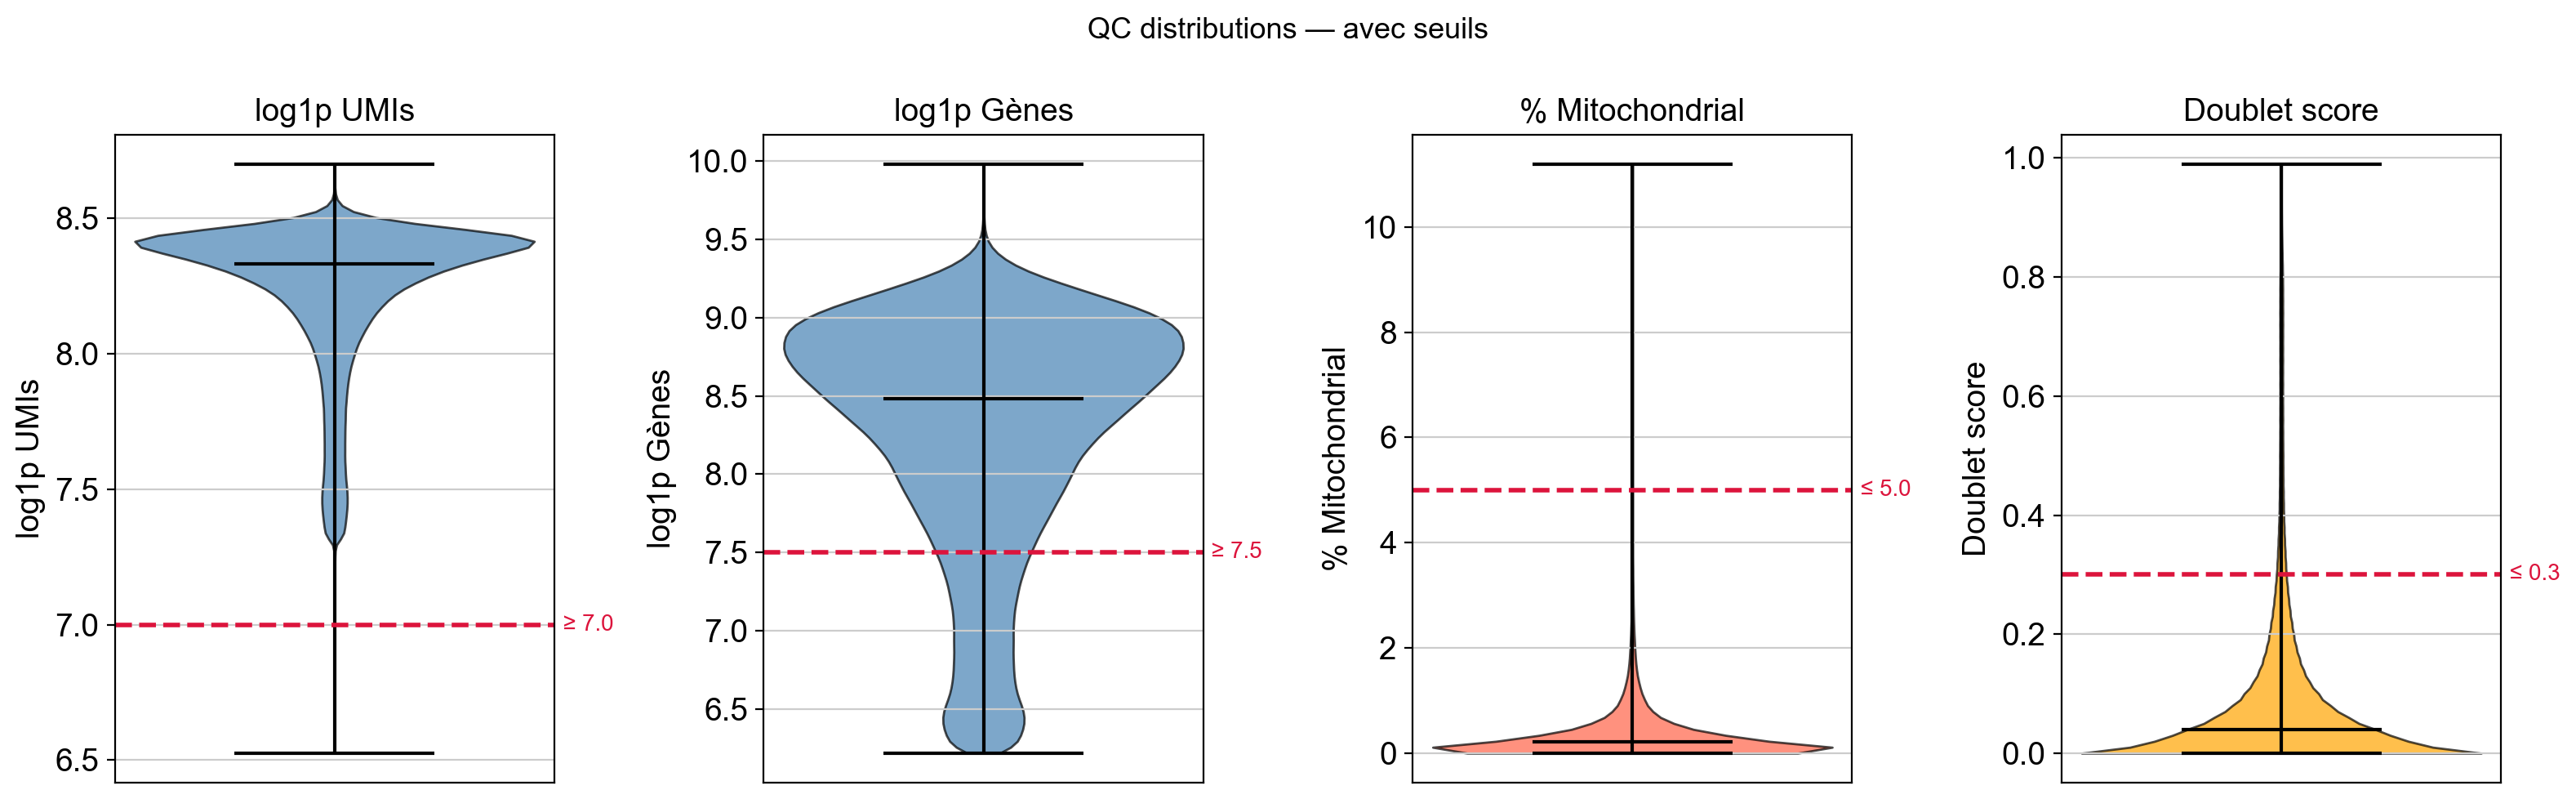

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics = [
    ("log1p_total_counts",      "log1p UMIs",      "steelblue"),
    ("log1p_n_genes_by_counts", "log1p Gènes",     "steelblue"),
    ("pct_counts_mt",           "% Mitochondrial", "tomato"),
    ("Doublet score",           "Doublet score",    "orange"),
]

for ax, (col, label, color) in zip(axes, metrics):
    vals = adata_rna.obs[col].dropna()
    vp = ax.violinplot(vals, showmedians=True)
    for body in vp["bodies"]:
        body.set_facecolor(color); body.set_edgecolor("black"); body.set_alpha(0.7)
    for key in ["cmedians", "cbars", "cmins", "cmaxes"]:
        vp[key].set_color("black")
    if col in qc_thresholds:
        direction, thr = qc_thresholds[col]
        ax.axhline(thr, color="crimson", linestyle="--", linewidth=2)
        symbol = "≥" if direction == "min" else "≤"
        ax.text(1.02, thr, f"{symbol} {thr}",
                transform=ax.get_yaxis_transform(),
                color="crimson", fontsize=10, va="center", ha="left")
    ax.set_title(label); ax.set_xticks([]); ax.set_ylabel(label)

plt.suptitle("QC distributions — avec seuils", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
print(f"Avant QC: {adata_rna.n_obs:,} cellules | {adata_rna.obs['Donor ID'].nunique()} donors\n")

mask_qc = pd.Series(True, index=adata_rna.obs_names)
for col, (direction, val) in qc_thresholds.items():
    vals = adata_rna.obs[col]
    crit = (vals >= val) if direction == "min" else (vals <= val)
    crit = crit.fillna(False)
    n_fail = (~crit).sum()
    print(f"{col:<35} {direction}={val} → exclut {n_fail:>7,} ({n_fail/adata_rna.n_obs*100:.1f}%)")
    mask_qc &= crit

mask_pps = adata_rna.obs["Continuous Pseudo-progression Score"].notna()

print(f"\nAprès QC            : {mask_qc.sum():,} cellules")
print(f"Après QC + PPS      : {(mask_qc & mask_pps).sum():,} cellules")
print(f"\nClass (QC+PPS) — valeurs disponibles :")
print(adata_rna.obs.loc[mask_qc & mask_pps, "Class"].value_counts().to_string())


Avant QC: 1,957,283 cellules | 89 donors

log1p_total_counts                  min=7.0 → exclut     216 (0.0%)
log1p_n_genes_by_counts             min=7.5 → exclut 322,261 (16.5%)
pct_counts_mt                       max=5.0 → exclut     989 (0.1%)
Doublet score                       max=0.3 → exclut 130,739 (6.7%)

Après QC            : 1,508,141 cellules
Après QC + PPS      : 1,373,022 cellules

Class (QC+PPS) — valeurs disponibles :
Class
Neuronal: Glutamatergic        740404
Neuronal: GABAergic            342187
Non-neuronal and Non-neural    290431


In [9]:
# 1. Sauvegarde des métadonnées PPS (un seul fichier commun)
donor_pps_df = (
    adata_rna.obs.loc[mask_qc & mask_pps,
                      ["Donor ID", "Continuous Pseudo-progression Score"]]
    .drop_duplicates(subset=["Donor ID"])
    .set_index("Donor ID")
)
donor_pps_df.to_csv(PPS_META)
print(f"✅ PPS sauvegardé : {PPS_META}  ({len(donor_pps_df)} donors)\n")

# 2. Fonction pseudobulk
def make_pseudobulk_rna(adata_sub, label):
    donors = adata_sub.obs["Donor ID"].unique()
    pb_data = {}
    for donor in donors:
        dmask = (adata_sub.obs["Donor ID"] == donor).values
        if sp.issparse(adata_sub.X):
            s = adata_sub.X[dmask].sum(axis=0).A1
        else:
            s = adata_sub.X[dmask].sum(axis=0)
        pb_data[donor] = s
    pb = pd.DataFrame(pb_data, index=adata_sub.var_names)
    print(f"  {label}: {len(donors)} donors × {pb.shape[0]} gènes")
    return pb

# 3. Pseudobulk par type cellulaire via colonne "Class"
# Valeurs exactes : "Neuronal: Glutamatergic" et "Neuronal: GABAergic"
print("Création des pseudobulks RNA:\n")
for cell_type, cfg in CELL_TYPES.items():
    class_name = cfg["class_name"]
    mask_class = adata_rna.obs["Class"] == class_name
    mask = mask_qc & mask_pps & mask_class
    n_cells = mask.sum()
    print(f"  {cell_type} (Class == '{class_name}'): {n_cells:,} cellules")
    if n_cells == 0:
        print(f"  ⚠️  ATTENTION : 0 cellules trouvées!")
        continue
    adata_sub = adata_rna[mask].copy()
    pb = make_pseudobulk_rna(adata_sub, cell_type)
    del adata_sub
    gc.collect()
    pb.to_csv(cfg["pb_path"])
    print(f"  ✅ Sauvegardé → {cfg['pb_path']}\n")

del adata_rna
gc.collect()
print("✅ Mémoire libérée")


✅ PPS sauvegardé : ../data/metadata/metadata_RNA_PPS.csv  (84 donors)

Création des pseudobulks RNA:

  Glu (Class == 'Neuronal: Glutamatergic'): 740,404 cellules
  Glu: 84 donors × 36601 gènes
  ✅ Sauvegardé → ../data/processed/pseudobulk_RNA_Glu.csv

  Gaba (Class == 'Neuronal: GABAergic'): 342,187 cellules
  Gaba: 84 donors × 36601 gènes
  ✅ Sauvegardé → ../data/processed/pseudobulk_RNA_Gaba.csv

✅ Mémoire libérée


In [10]:
donor_pps = pd.read_csv(PPS_META, index_col=0).iloc[:, 0]
print(f"Donors avec PPS disponibles : {len(donor_pps)}\n")

common_donors_by_ct = {}

for cell_type, cfg in CELL_TYPES.items():
    pb_df   = pd.read_csv(cfg["pb_path"], index_col=0, nrows=0)   # header only
    atac_df = pd.read_csv(cfg["atac_path"], sep="\t", index_col=0, nrows=0)

    donors_rna  = set(pb_df.columns)
    donors_atac = set(atac_df.columns)
    donors_pps  = set(donor_pps.index)

    common = sorted(donors_rna & donors_atac & donors_pps)
    common_donors_by_ct[cell_type] = common

    print(f"=== {cell_type} ===")
    print(f"  Donors RNA pseudobulk : {len(donors_rna)}")
    print(f"  Donors ATAC           : {len(donors_atac)}")
    print(f"  Donors avec PPS       : {len(donors_pps)}")
    print(f"  Donors communs (∩)    : {len(common)}")
    only_rna  = donors_rna  - donors_atac - donors_pps
    only_atac = donors_atac - donors_rna  - donors_pps
    print(f"  Exclus (RNA only)     : {len(only_rna)}")
    print(f"  Exclus (ATAC only)    : {len(only_atac)}")
    print()

Donors avec PPS disponibles : 84

=== Glu ===
  Donors RNA pseudobulk : 84
  Donors ATAC           : 73
  Donors avec PPS       : 84
  Donors communs (∩)    : 73
  Exclus (RNA only)     : 0
  Exclus (ATAC only)    : 0

=== Gaba ===
  Donors RNA pseudobulk : 84
  Donors ATAC           : 73
  Donors avec PPS       : 84
  Donors communs (∩)    : 73
  Exclus (RNA only)     : 0
  Exclus (ATAC only)    : 0



In [11]:
print("=== Résumé final ===\n")
for cell_type, donors in common_donors_by_ct.items():
    print(f"{cell_type}: {len(donors)} donneurs communs prêts pour l'analyse")

print(f"\nFichiers produits :")
print(f"  PPS metadata   : {PPS_META}")
for ct, cfg in CELL_TYPES.items():
    print(f"  Pseudobulk {ct} : {cfg['pb_path']}")

=== Résumé final ===

Glu: 73 donneurs communs prêts pour l'analyse
Gaba: 73 donneurs communs prêts pour l'analyse

Fichiers produits :
  PPS metadata   : ../data/metadata/metadata_RNA_PPS.csv
  Pseudobulk Glu : ../data/processed/pseudobulk_RNA_Glu.csv
  Pseudobulk Gaba : ../data/processed/pseudobulk_RNA_Gaba.csv
